# Notebook 03 — EDA y Feature Engineering

**Fase 2 · Módulo 2A–2C** — Análisis exploratorio de datos y construcción del vector de características clínicas.

**Entrada:** `data/interim/unified_raw_v2.csv` (3.781 registros: IDEXX + DAP)  
**Salida:** `data/interim/unified_clean.csv`, `data/interim/featured_raw.csv`

| Sección | Contenido |
|---|---|
| **0** | Dependencias y configuración |
| **1** | Correcciones de cierre de Fase 1 (consolidación de columnas, deduplicación) |
| **2** | EDA comparativo IDEXX vs DAP (distribuciones, outliers, correlaciones) |
| **3** | Feature engineering clínico (flags, ratios hematológicos, leucograma de estrés) |
| **4** | Codificación de variables morfológicas DAP |
| **5** | Resumen de variables y guardado |
| **6** | Verificación de integridad |


### Guia rapida del codigo

- Parte de `data/interim/unified_raw_v2.csv` y produce un dataset limpio.
- Revisa distribuciones, outliers, correlaciones y diferencias IDEXX vs DAP.
- Construye flags clinicos, ratios, patron de leucograma de estres y variables morfologicas.
- Exporta `data/interim/featured_raw.csv` y figuras/tablas en `outputs/`.


## 0. Dependencias y configuracion

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pathlib
import warnings
from IPython.display import display, Image

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", font_scale=1.0)

# Rutas del proyecto
# Se escala hacia arriba desde el CWD hasta encontrar la raiz real del repo
# (carpetas esperadas: data/ y scripts/)
_cwd = pathlib.Path.cwd()
PROJECT_ROOT = _cwd
while PROJECT_ROOT.parent != PROJECT_ROOT:
    if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "scripts").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if not ((PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "scripts").exists()):
    raise RuntimeError(
        f"No se pudo localizar la raiz del proyecto (data/ y scripts/). "
        f"CWD actual: {_cwd}"
    )

DATA_INTERIM   = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS        = PROJECT_ROOT / "outputs"

for d in [DATA_INTERIM, DATA_PROCESSED, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename, outputs_dir=OUTPUTS):
    """Guarda la figura, cierra el objeto y muestra inline."""
    path = outputs_dir / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))
    print(f"Guardado: {path}")

print(f"Raiz del proyecto : {PROJECT_ROOT}")
print(f"Datos intermedios : {DATA_INTERIM}")
print(f"Salidas graficas  : {OUTPUTS}")

Raiz del proyecto : /home/edwinb/tesis/hemogramas-proyectoICC
Datos intermedios : /home/edwinb/tesis/hemogramas-proyectoICC/data/interim
Salidas graficas  : /home/edwinb/tesis/hemogramas-proyectoICC/outputs


---
## 1. Correcciones de cierre de Fase 1

Antes de iniciar el analisis exploratorio, se aplican dos correcciones al dataset
heredado de Fase 1:

1. **Consolidacion de columnas duplicadas.** Las variables hemoglobina, hematocrito
   y plaquetocrito estan almacenadas en dos columnas cada una: una con el nombre
   IDEXX (`Hemoglobin`, `Hematocrit`, `Plateletcrit`) y otra con el nombre DAP
   (`HGB`, `HCT`, `PCT`). Cada columna tiene valores solo para su fuente y NaN
   para la otra. Se fusionan en la columna canonica (`HGB`, `HCT`, `PCT`) y se
   eliminan las columnas redundantes.

2. **Deduplicacion por `record_uuid`.** Existen registros IDEXX duplicados
   (mismo paciente y fecha capturado en dos paginas distintas del PDF). Se
   conserva la primera ocurrencia.

In [2]:
# 1.1 Carga del dataset de Fase 1
INPUT_CSV = DATA_INTERIM / "unified_raw_v2.csv"
df = pd.read_csv(INPUT_CSV)
print(f"Registros cargados: {len(df):,}")
print(f"Columnas          : {len(df.columns)}")

Registros cargados: 3,755
Columnas          : 89


### 1.1 Consolidacion de columnas duplicadas

In [3]:
# Mapeo: nombre canonico -> nombre alternativo IDEXX
CONSOLIDATE = {
    "HGB": "Hemoglobin",
    "HCT": "Hematocrit",
    "PCT": "Plateletcrit",
}

for canonical, idexx_name in CONSOLIDATE.items():
    if idexx_name not in df.columns:
        print(f"  {idexx_name} no encontrada, se omite.")
        continue
    if canonical not in df.columns:
        # Solo existe la columna IDEXX: renombrar directamente
        df.rename(columns={idexx_name: canonical}, inplace=True)
        print(f"  {idexx_name} renombrada a {canonical}")
    else:
        # Ambas columnas existen: fusionar valores
        fill_mask = df[canonical].isna() & df[idexx_name].notna()
        n_filled = fill_mask.sum()
        df.loc[fill_mask, canonical] = df.loc[fill_mask, idexx_name]
        df.drop(columns=[idexx_name], inplace=True)
        print(f"  {idexx_name} -> {canonical}: {n_filled:,} valores fusionados, columna eliminada")

print()
print("Completitud tras consolidacion:")
for col in ["HGB", "HCT", "PCT"]:
    if col in df.columns:
        pct = df[col].notna().mean() * 100
        print(f"  {col}: {pct:.1f}%")
    else:
        print(f"  {col}: columna no presente")

  Hemoglobin no encontrada, se omite.
  Hematocrit no encontrada, se omite.
  Plateletcrit no encontrada, se omite.

Completitud tras consolidacion:
  HGB: 99.8%
  HCT: 99.9%
  PCT: 98.4%


### 1.2 Deduplicacion por `record_uuid`

In [4]:
before = len(df)
df = df.drop_duplicates(subset="record_uuid", keep="first").reset_index(drop=True)
removed = before - len(df)
print(f"Registros eliminados por UUID duplicado: {removed}")
print(f"Registros tras deduplicacion          : {len(df):,}")

Registros eliminados por UUID duplicado: 0
Registros tras deduplicacion          : 3,755


### 1.3 Guardado del dataset limpio

In [5]:
CLEAN_CSV = DATA_INTERIM / "unified_clean.csv"
df.to_csv(CLEAN_CSV, index=False)
print(f"Guardado: {CLEAN_CSV}")
print(f"Registros: {len(df):,} | Columnas: {len(df.columns)}")

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/data/interim/unified_clean.csv
Registros: 3,755 | Columnas: 89


---
## 2. Analisis Exploratorio de Datos (Modulo 2A)

El EDA se ejecuta sobre `unified_clean.csv` con separacion por fuente
(IDEXX vs DAP) para verificar compatibilidad de distribuciones antes de
construir variables derivadas.

In [6]:
# Separar subconjuntos por fuente
idexx = df[df["source_dataset"] == "IDEXX"].copy()
dap   = df[df["source_dataset"] == "DAP"].copy()

print(f"IDEXX : {len(idexx):,} registros")
print(f"DAP   : {len(dap):,} registros")
print(f"Total : {len(df):,} registros")

IDEXX : 2,454 registros
DAP   : 1,301 registros
Total : 3,755 registros


### 2.1 Distribuciones univariadas por fuente

Para cada variable CBC principal se generan histogramas superpuestos IDEXX vs DAP.
El objetivo es verificar que las distribuciones se solapan en al menos el 85% de
su rango. Diferencias de media superiores al 20% requieren investigacion.

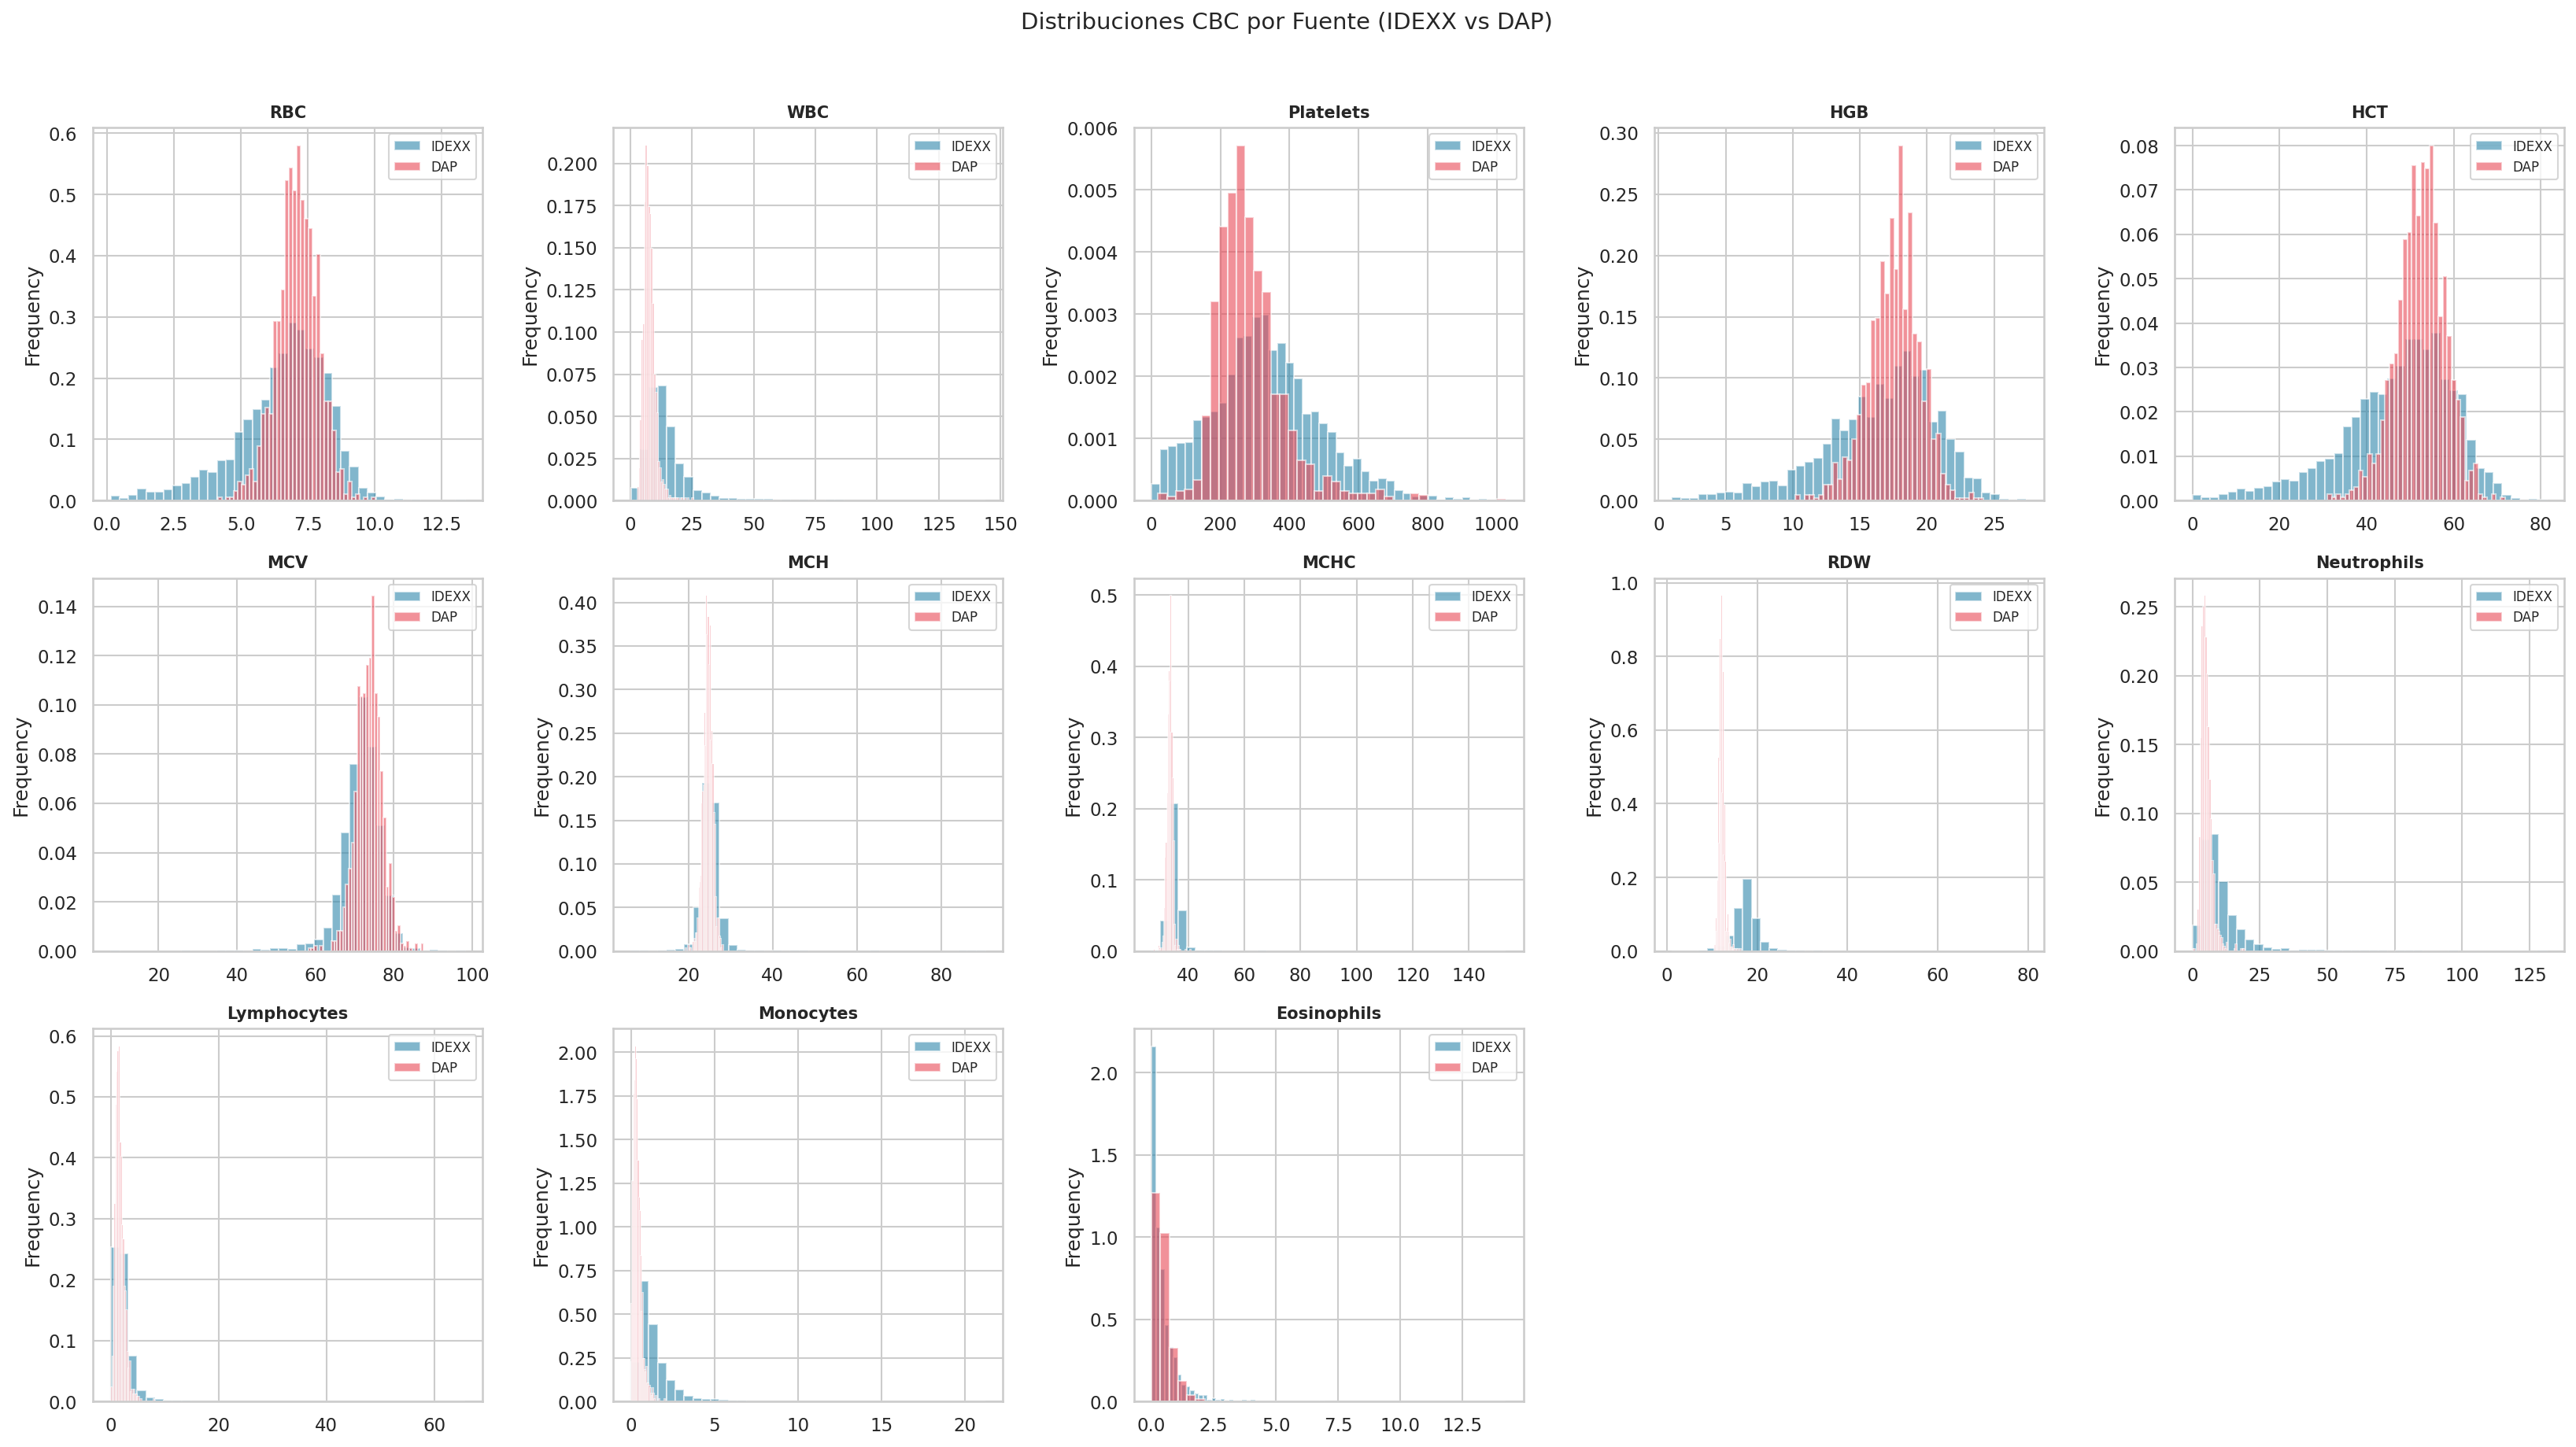

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/eda_distributions.png


In [7]:
CBC_VARS = [
    "RBC", "WBC", "Platelets", "HGB", "HCT", "MCV", "MCH", "MCHC",
    "RDW", "Neutrophils", "Lymphocytes", "Monocytes", "Eosinophils",
]

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, var in enumerate(CBC_VARS):
    ax = axes[i]
    if var in idexx.columns and idexx[var].notna().sum() > 10:
        idexx[var].dropna().plot(
            kind="hist", ax=ax, alpha=0.6, bins=40,
            color="#2E86AB", label="IDEXX", density=True,
        )
    if var in dap.columns and dap[var].notna().sum() > 10:
        dap[var].dropna().plot(
            kind="hist", ax=ax, alpha=0.6, bins=40,
            color="#E84855", label="DAP", density=True,
        )
    ax.set_title(var, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

# Ocultar ejes sobrantes
for j in range(len(CBC_VARS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuciones CBC por Fuente (IDEXX vs DAP)", fontsize=14, y=1.02)
plt.tight_layout()
save_and_show(fig, "eda_distributions.png")

### 2.2 Deteccion de outliers extremos

Los outliers fuera de rangos fisiologicos caninos pueden ser errores de
extraccion del PDF (decimal desplazado) o casos patologicos genuinos.
Se identifican y se marcan con un flag `extraction_error` para excluirlos
del entrenamiento sin eliminarlos del archivo.

In [8]:
# Rangos fisiologicos caninos de referencia
PHYSIOLOGICAL_BOUNDS = {
    "RBC":         (2.5,   10.5),   # M/uL
    "WBC":         (3.0,   30.0),   # K/uL
    "Platelets":   (20.0,  900.0),  # K/uL
    "HGB":         (6.0,   22.0),   # g/dL
    "HCT":         (20.0,  70.0),   # %
    "MCV":         (55.0,  90.0),   # fL
    "Neutrophils": (0.0,   25.0),   # K/uL
    "Lymphocytes": (0.0,   15.0),   # K/uL
    "Monocytes":   (0.0,    5.0),   # K/uL
    "Eosinophils": (0.0,    5.0),   # K/uL
}

outlier_rows = set()
outlier_report = {}

for var, (lo, hi) in PHYSIOLOGICAL_BOUNDS.items():
    if var not in df.columns:
        continue
    mask_low  = df[var] < lo
    mask_high = df[var] > hi
    n_low  = mask_low.sum()
    n_high = mask_high.sum()
    outlier_rows.update(df.index[mask_low | mask_high].tolist())
    outlier_report[var] = {"below_min": int(n_low), "above_max": int(n_high)}
    print(f"{var:<15} | fuera de rango bajo: {n_low:>4} | alto: {n_high:>4}")

# Marcar con flag
df["extraction_error"] = False
df.loc[list(outlier_rows), "extraction_error"] = True
n_errors = df["extraction_error"].sum()
print(f"\nTotal registros marcados con extraction_error: {n_errors}")
print(f"Porcentaje: {n_errors / len(df) * 100:.1f}%")

RBC             | fuera de rango bajo:   72 | alto:    5
WBC             | fuera de rango bajo:   51 | alto:  144
Platelets       | fuera de rango bajo:    9 | alto:    7
HGB             | fuera de rango bajo:   54 | alto:  164
HCT             | fuera de rango bajo:  102 | alto:   22
MCV             | fuera de rango bajo:   28 | alto:    2
Neutrophils     | fuera de rango bajo:    0 | alto:  122
Lymphocytes     | fuera de rango bajo:    0 | alto:   16
Monocytes       | fuera de rango bajo:    0 | alto:   54
Eosinophils     | fuera de rango bajo:    0 | alto:    6

Total registros marcados con extraction_error: 481
Porcentaje: 12.8%


### 2.3 Matriz de correlacion por fuente

La matriz de correlacion permite identificar colinealidades entre
variables CBC. Los pares con alta correlacion (por ejemplo HGB-HCT ~0.97)
se documentan para que la Fase 3 los considere al interpretar importancia
de variables con SHAP.

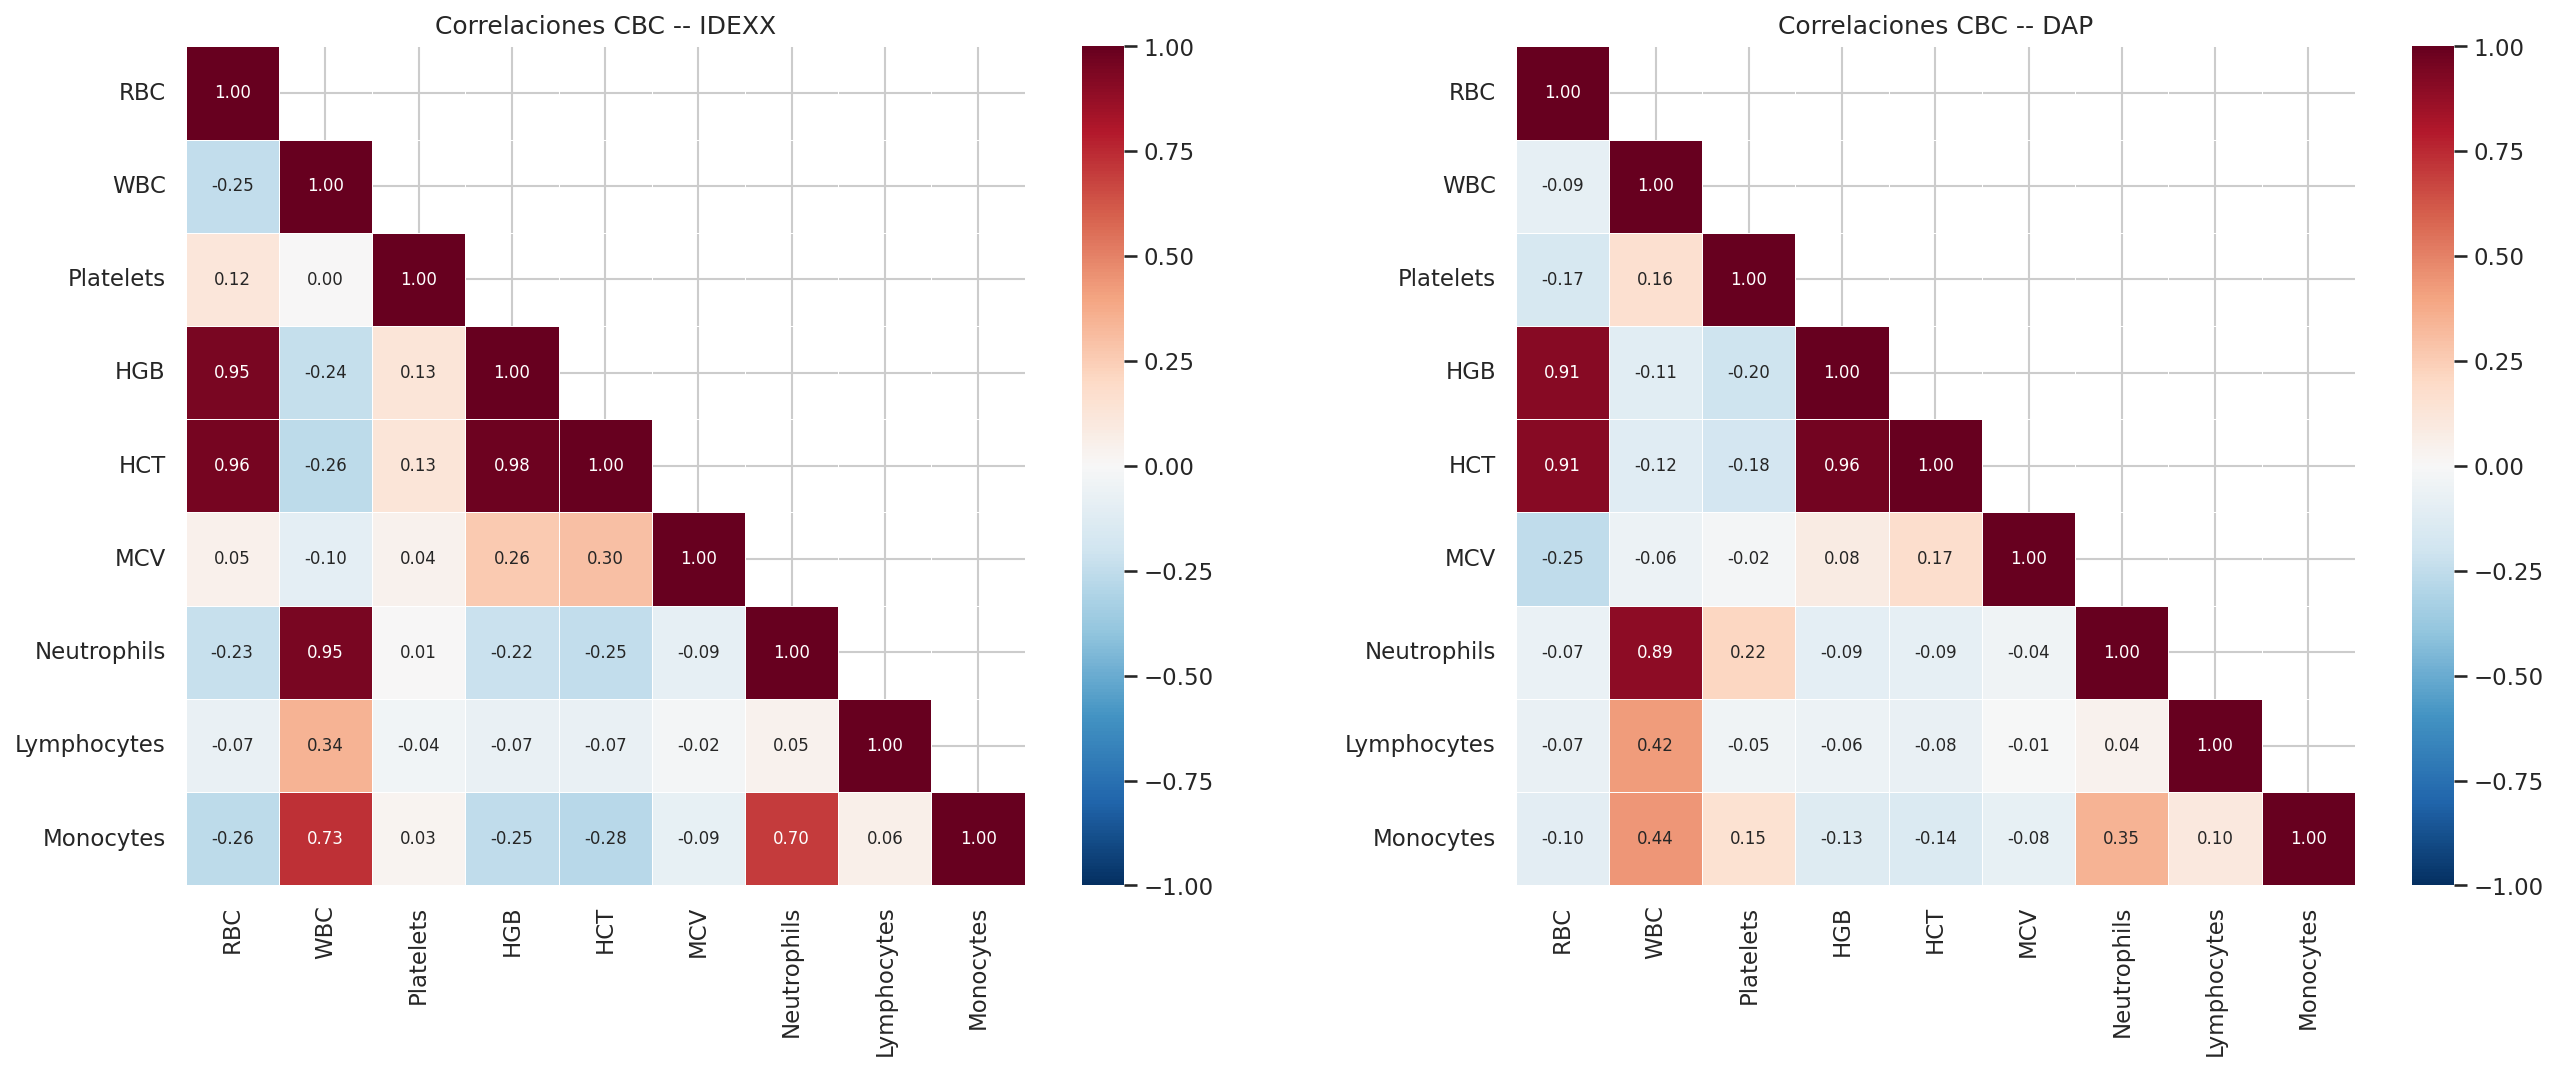

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/eda_correlations.png


In [9]:
corr_vars = [
    "RBC", "WBC", "Platelets", "HGB", "HCT", "MCV",
    "Neutrophils", "Lymphocytes", "Monocytes",
]
corr_available = [v for v in corr_vars if v in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (source_name, subset) in zip(axes, [("IDEXX", idexx), ("DAP", dap)]):
    corr = subset[corr_available].corr()
    mask_tri = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr, mask=mask_tri, annot=True, fmt=".2f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, ax=ax, square=True,
        linewidths=0.4, annot_kws={"size": 8},
    )
    ax.set_title(f"Correlaciones CBC -- {source_name}", fontsize=12)

plt.tight_layout()
save_and_show(fig, "eda_correlations.png")

### 2.3b Boxplots comparativos IDEXX vs DAP

Boxplots lado a lado de 9 variables CBC clave para comparar
distribuciones y detectar outliers entre fuentes.

/tmp/ipykernel_11418/4193972772.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_box, labels=labels_box, patch_artist=True,
/tmp/ipykernel_11418/4193972772.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_box, labels=labels_box, patch_artist=True,
/tmp/ipykernel_11418/4193972772.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_box, labels=labels_box, patch_artist=True,
/tmp/ipykernel_11418/4193972772.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; suppo

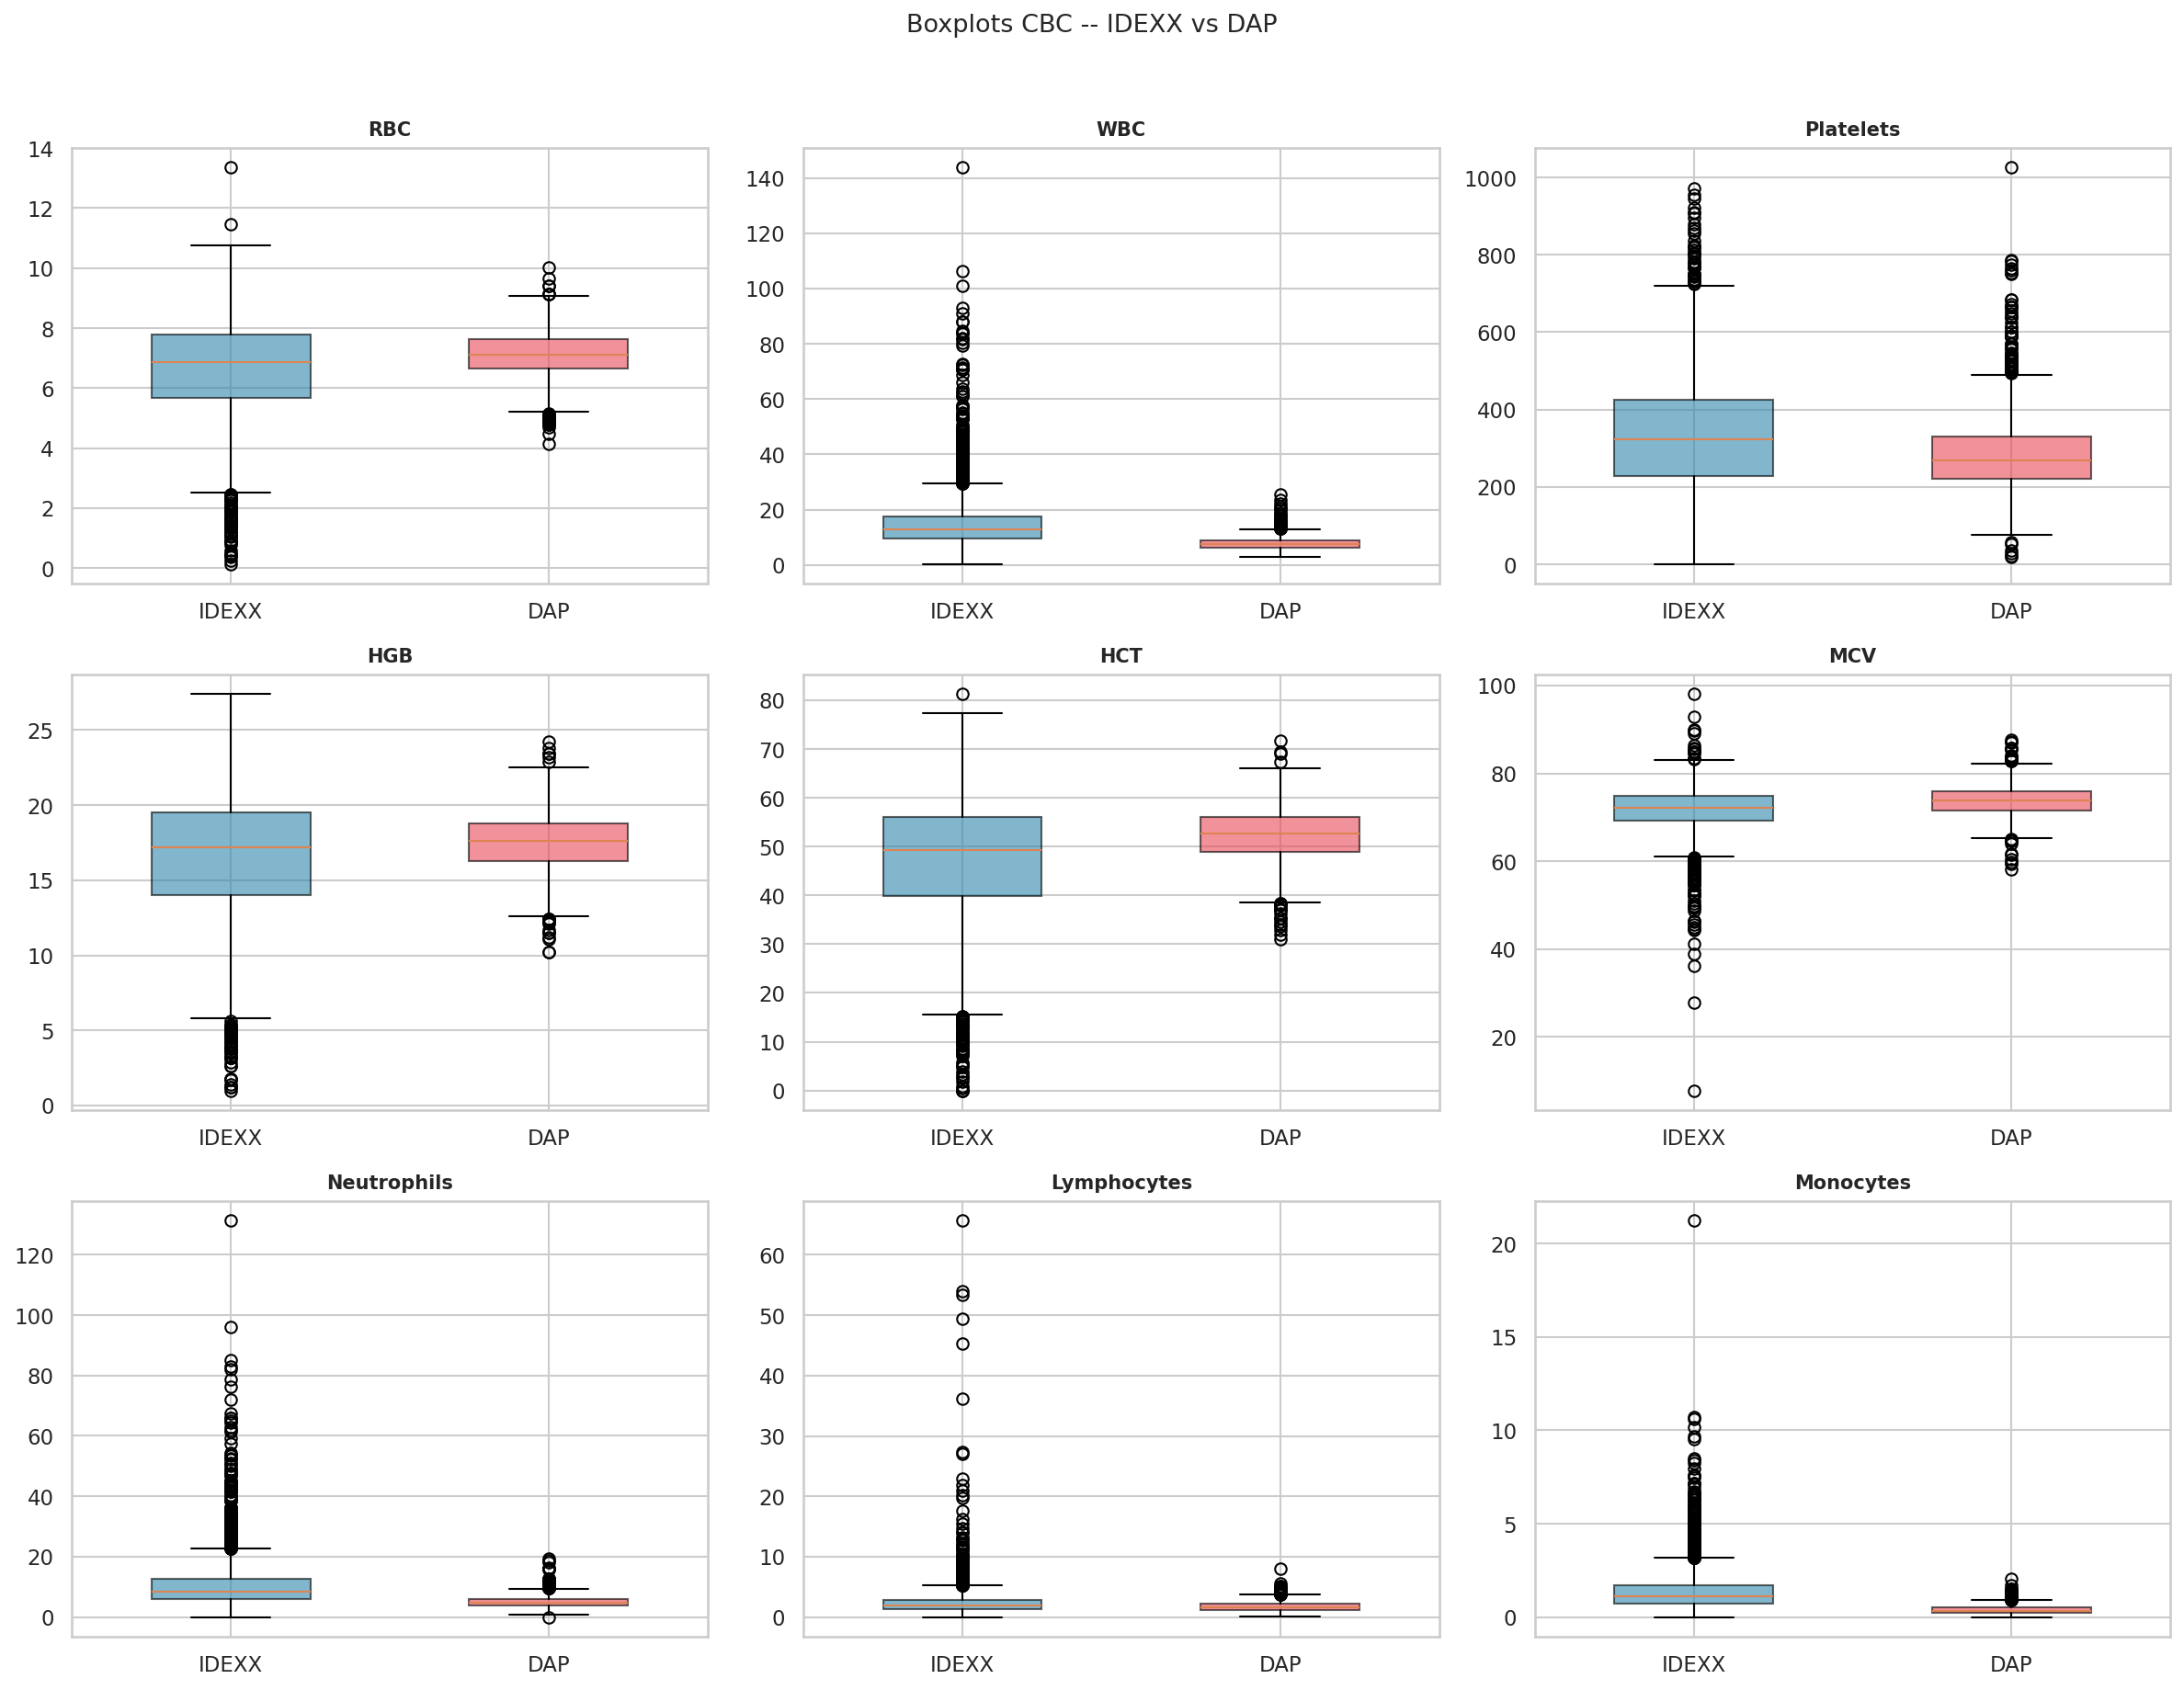

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb03_outliers_boxplots.png


In [10]:
BOX_VARS = ["RBC", "WBC", "Platelets", "HGB", "HCT", "MCV",
            "Neutrophils", "Lymphocytes", "Monocytes"]
box_available = [v for v in BOX_VARS if v in df.columns]

n_vars = len(box_available)
ncols = 3
nrows = (n_vars + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(box_available):
    data_box = []
    labels_box = []
    for src_name, subset in [("IDEXX", idexx), ("DAP", dap)]:
        if var in subset.columns:
            vals = subset[var].dropna()
            if len(vals) > 0:
                data_box.append(vals.values)
                labels_box.append(src_name)
    if data_box:
        bp = axes[i].boxplot(data_box, labels=labels_box, patch_artist=True,
                             widths=0.5)
        colors = ["#2E86AB", "#E84855"]
        for patch, color in zip(bp["boxes"], colors[:len(bp["boxes"])]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
    axes[i].set_title(var, fontsize=10, fontweight="bold")

for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots CBC -- IDEXX vs DAP", fontsize=13, y=1.02)
plt.tight_layout()
save_and_show(fig, "nb03_outliers_boxplots.png")

### 2.4 Resumen estadistico por fuente

Tabla condensada con media, desviacion estandar, mediana y cobertura de cada
variable CBC, segmentada por fuente.

In [11]:
summary_rows = []
for var in CBC_VARS:
    if var not in df.columns:
        continue
    for src_name, subset in [("IDEXX", idexx), ("DAP", dap)]:
        vals = subset[var].dropna()
        summary_rows.append({
            "Variable": var,
            "Fuente": src_name,
            "N": len(vals),
            "Cobertura_%": round(len(vals) / len(subset) * 100, 1),
            "Media": round(vals.mean(), 2) if len(vals) else None,
            "DE": round(vals.std(), 2) if len(vals) else None,
            "Mediana": round(vals.median(), 2) if len(vals) else None,
            "Min": round(vals.min(), 2) if len(vals) else None,
            "Max": round(vals.max(), 2) if len(vals) else None,
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

   Variable Fuente    N  Cobertura_%  Media     DE  Mediana   Min     Max
        RBC  IDEXX 2450         99.8   6.57   1.73     6.86  0.14   13.36
        RBC    DAP 1301        100.0   7.12   0.78     7.12  4.15   10.03
        WBC  IDEXX 2429         99.0  15.13  10.80    12.70  0.34  143.85
        WBC    DAP 1301        100.0   7.79   2.41     7.45  2.85   25.45
  Platelets  IDEXX 2454        100.0 332.81 158.97   324.00  1.00  972.00
  Platelets    DAP 1301        100.0 286.79 101.92   269.00 20.00 1026.00
        HGB  IDEXX 2446         99.7  16.48   4.29    17.20  1.00   27.40
        HGB    DAP 1301        100.0  17.52   1.92    17.60 10.20   24.20
        HCT  IDEXX 2451         99.9  47.13  12.88    49.20  0.00   81.30
        HCT    DAP 1301        100.0  52.43   5.61    52.70 31.00   71.70
        MCV  IDEXX 2454        100.0  71.66   5.31    72.10  7.80   98.10
        MCV    DAP 1301        100.0  73.74   3.42    73.80 58.20   87.60
        MCH  IDEXX 2448         99.8  

### 2.5 Tabla resumen estadistico CBC

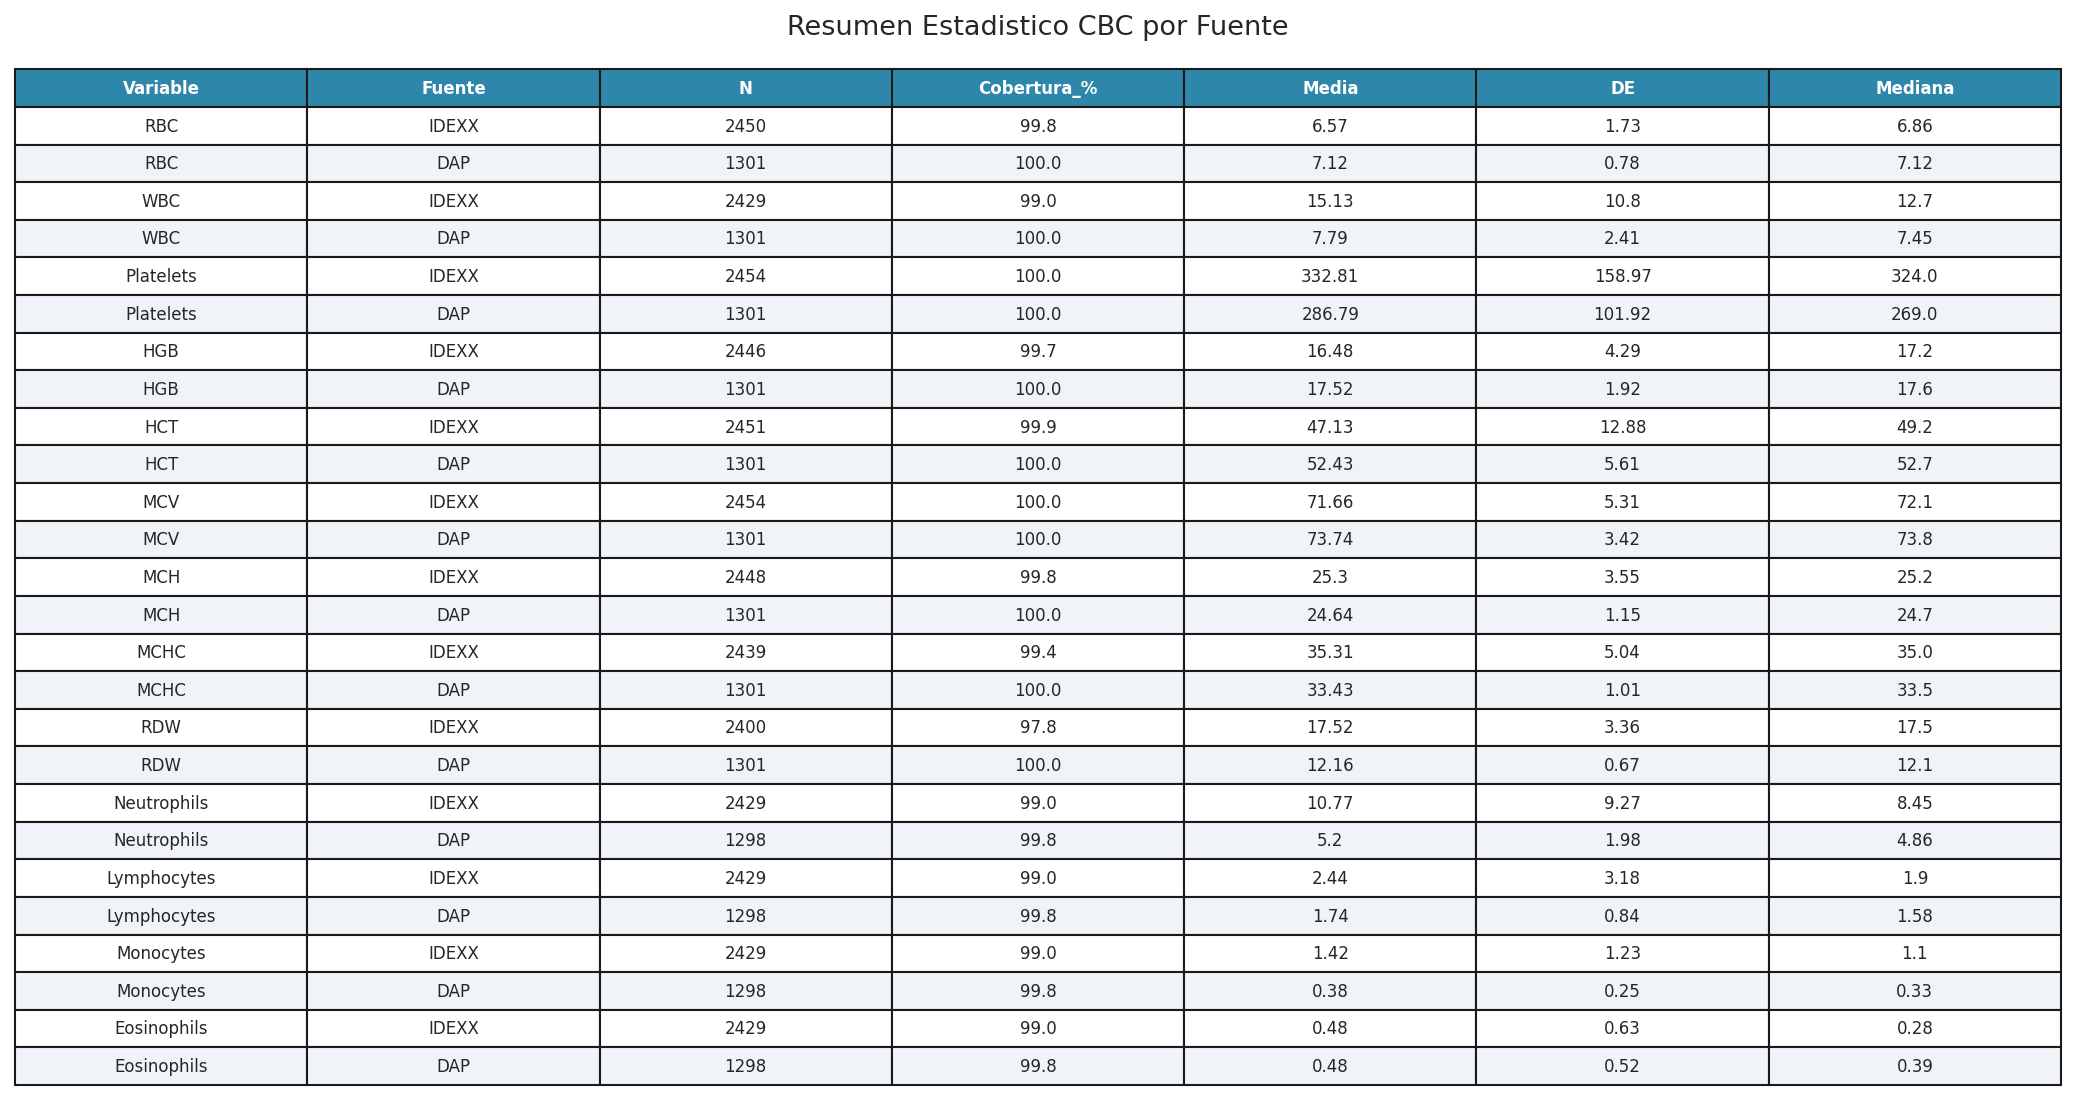

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb03_summary_estadistico_cbc.png


In [12]:
# Tabla visual del resumen estadistico
df_summary.to_csv(OUTPUTS / "nb03_summary_estadistico_cbc.csv", index=False)

cols_show = ["Variable", "Fuente", "N", "Cobertura_%", "Media", "DE", "Mediana"]
df_table = df_summary[cols_show].copy()

fig, ax = plt.subplots(figsize=(14, max(4, len(df_table) * 0.25 + 1)))
ax.axis("off")
tbl = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.3)

# Header styling
for j in range(len(df_table.columns)):
    cell = tbl[0, j]
    cell.set_facecolor("#2E86AB")
    cell.set_text_props(color="white", fontweight="bold")

# Alternate row colors
for i in range(1, len(df_table) + 1):
    for j in range(len(df_table.columns)):
        if i % 2 == 0:
            tbl[i, j].set_facecolor("#F0F4F8")

ax.set_title("Resumen Estadistico CBC por Fuente", fontsize=13, pad=20)
fig.tight_layout()
save_and_show(fig, "nb03_summary_estadistico_cbc.png")

---
## 3. Feature Engineering (Modulo 2B)

### Principio de diseno

Las variables derivadas capturan relaciones clinicas que los valores
individuales no expresan por si solos. Cada feature tiene justificacion
clinica explicita, no es resultado de exploracion ciega.

Las variables que no cuenten con respaldo en la literatura veterinaria
no se incluyen, aunque muestren correlacion empirica con la etiqueta.

### 3.1 Flags clinicos primarios

In [13]:
def build_clinical_flags(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera variables binarias basadas en umbrales fisiologicos caninos.

    Referencias:
      - Cowell & Tyler, Diagnostic Cytology and Hematology of the Dog and Cat.
      - Thrall et al., Veterinary Hematology and Clinical Chemistry, 2nd Ed.
    """
    d = df.copy()

    # -- Trombocitopenia (variable objetivo primaria) --
    # Umbral < 200 K/uL: leve-moderada; < 100 K/uL: severa con riesgo hemorragico
    d["flag_thrombocytopenia"]        = (d["Platelets"] < 200).astype(int)
    d["flag_thrombocytopenia_severe"] = (d["Platelets"] < 100).astype(int)

    # -- Alteraciones linfocitarias (segunda variable objetivo) --
    d["flag_lymphopenia"]   = (d["Lymphocytes"] < 1.0).astype(int)
    d["flag_lymphocytosis"] = (d["Lymphocytes"] > 5.0).astype(int)

    # -- Neutrofilia y neutropenia --
    d["flag_neutrophilia"] = (d["Neutrophils"] > 11.0).astype(int)
    d["flag_neutropenia"]  = (d["Neutrophils"] < 2.9).astype(int)

    # -- Leucocitosis y leucopenia --
    d["flag_leukocytosis"] = (d["WBC"] > 17.0).astype(int)
    d["flag_leukopenia"]   = (d["WBC"] < 5.5).astype(int)

    return d

df = build_clinical_flags(df)

# Verificacion
flag_cols = [c for c in df.columns if c.startswith("flag_")]
print(f"Flags generados: {len(flag_cols)}")
for c in sorted(flag_cols):
    n_pos = df[c].sum()
    print(f"  {c:<35} positivos: {n_pos:>5} ({n_pos / len(df) * 100:.1f}%)")

Flags generados: 8
  flag_leukocytosis                   positivos:   651 (17.3%)
  flag_leukopenia                     positivos:   309 (8.2%)
  flag_lymphocytosis                  positivos:   148 (3.9%)
  flag_lymphopenia                    positivos:   610 (16.2%)
  flag_neutropenia                    positivos:   180 (4.8%)
  flag_neutrophilia                   positivos:   817 (21.8%)
  flag_thrombocytopenia               positivos:   674 (17.9%)
  flag_thrombocytopenia_severe        positivos:   185 (4.9%)


### 3.2 Ratios hematologicos

Las relaciones entre parametros capturan patrones que los valores absolutos
no detectan individualmente.

- **NLR (Neutrofilos/Linfocitos):** Elevado en inflamacion sistemica, sepsis,
  respuesta glucocorticoide. Referencia: Yoon et al., JVIM 2020.
- **PLR (Plaquetas/Linfocitos):** Marcador de activacion inmune en hemoparasitos.
- **MLR (Monocitos/Linfocitos):** Elevado en monocitosis relativa por inflamacion cronica.

In [14]:
def build_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula ratios hematologicos con justificacion clinica.
    Se anade epsilon para evitar division por cero.
    """
    d = df.copy()
    EPS = 0.01

    # Ratio Neutrofilos / Linfocitos
    d["ratio_NLR"] = d["Neutrophils"] / (d["Lymphocytes"] + EPS)

    # Ratio Plaquetas / Linfocitos
    d["ratio_PLR"] = d["Platelets"] / (d["Lymphocytes"] + EPS)

    # Ratio Monocitos / Linfocitos
    d["ratio_MLR"] = d["Monocytes"] / (d["Lymphocytes"] + EPS)

    # Porcentaje de linfocitos sobre WBC (si no existe ya)
    if "Lymphocytes_pct" not in d.columns:
        d["Lymphocytes_pct_calc"] = (d["Lymphocytes"] / (d["WBC"] + EPS)) * 100

    return d

df = build_ratio_features(df)

ratio_cols = [c for c in df.columns if c.startswith("ratio_")]
print(f"Ratios generados: {len(ratio_cols)}")
for c in sorted(ratio_cols):
    vals = df[c].dropna()
    print(f"  {c:<35} media={vals.mean():.2f}  mediana={vals.median():.2f}  max={vals.max():.1f}")

Ratios generados: 3
  ratio_MLR                           media=0.77  mediana=0.39  max=89.0
  ratio_NLR                           media=6.38  mediana=3.72  max=162.0
  ratio_PLR                           media=243.27  mediana=167.65  max=70900.0


### 3.3 Leucograma de estres

El leucograma de estres es un patron hematologico definido por la activacion
del eje hipotalamo-hipofisis-adrenal. Se caracteriza por neutrofilia madura,
linfopenia y eosinopenia simultaneas. Es clinicamente importante porque puede
simular un proceso infeccioso subyacente.

In [15]:
def build_stress_leukogram(df: pd.DataFrame) -> pd.DataFrame:
    """
    Codifica el leucograma de estres como variable binaria compuesta.
    Criterios: neutrofilia (Neutrophils > 11.0) + linfopenia (Lymphocytes < 1.0)
    simultaneas, con ausencia de eosinofilia (Eosinophils < 0.5).
    """
    d = df.copy()

    crit_neutrophilia = d["Neutrophils"] > 11.0
    crit_lymphopenia  = d["Lymphocytes"] < 1.0
    crit_eosinopenia  = d["Eosinophils"] < 0.5

    d["pattern_stress_leukogram"] = (
        crit_neutrophilia & crit_lymphopenia & crit_eosinopenia
    ).astype(int)

    n = d["pattern_stress_leukogram"].sum()
    print(f"Leucograma de estres detectado: {n} registros ({n / len(d) * 100:.1f}%)")

    return d

df = build_stress_leukogram(df)

Leucograma de estres detectado: 159 registros (4.2%)


### 3.4 Indice de anemia

La anemia normocitica normocromica (MCV y MCHC en rango) con RBC bajo es
frecuente en enfermedad cronica o hemoparasitos. Se generan flags de anemia
y clasificacion morfologica segun indices eritrocitarios.

In [16]:
def build_anemia_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Variables derivadas de la serie roja.
    Umbral de anemia: HGB < 12 g/dL (conservador para ambos sexos).
    """
    d = df.copy()

    if "HGB" in d.columns:
        d["flag_anemia"] = (d["HGB"] < 12.0).astype(int)
        n = d["flag_anemia"].sum()
        print(f"flag_anemia: {n} registros ({n / len(d) * 100:.1f}%)")

    if all(c in d.columns for c in ["MCV", "MCHC"]):
        d["flag_microcytic"]  = (d["MCV"] < 62.0).astype(int)
        d["flag_macrocytic"]  = (d["MCV"] > 82.0).astype(int)
        d["flag_hypochromic"] = (d["MCHC"] < 31.0).astype(int)
        print(f"flag_microcytic : {d['flag_microcytic'].sum()}")
        print(f"flag_macrocytic : {d['flag_macrocytic'].sum()}")
        print(f"flag_hypochromic: {d['flag_hypochromic'].sum()}")

    return d

df = build_anemia_index(df)

flag_anemia: 347 registros (9.2%)
flag_microcytic : 93
flag_macrocytic : 35
flag_hypochromic: 34


### 3.5 Estado plaquetario morfologico

MPV elevado con trombocitopenia sugiere trombopoyesis activa (destruccion
periferica). MPV bajo con trombocitopenia sugiere fallo medular. El ratio
MPV/Plaquetas es un marcador exploratorio de activacion plaquetaria.

In [17]:
def build_platelet_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features adicionales de la serie plaquetaria."""
    d = df.copy()

    if "MPV" in d.columns:
        # Macroplaquetas: sugiere respuesta regenerativa
        d["flag_macro_platelets"] = (d["MPV"] > 12.5).astype(int)
        print(f"flag_macro_platelets: {d['flag_macro_platelets'].sum()}")

        # MPV / Plaquetas ratio
        d["ratio_MPV_PLT"] = d["MPV"] / (d["Platelets"] + 0.01)
        print(f"ratio_MPV_PLT media: {d['ratio_MPV_PLT'].mean():.4f}")
    else:
        print("Columna MPV no encontrada; se omiten features plaquetarias.")

    return d

df = build_platelet_features(df)

flag_macro_platelets: 1127
ratio_MPV_PLT media: 0.0628


### 3.6 Visualizacion de features derivados

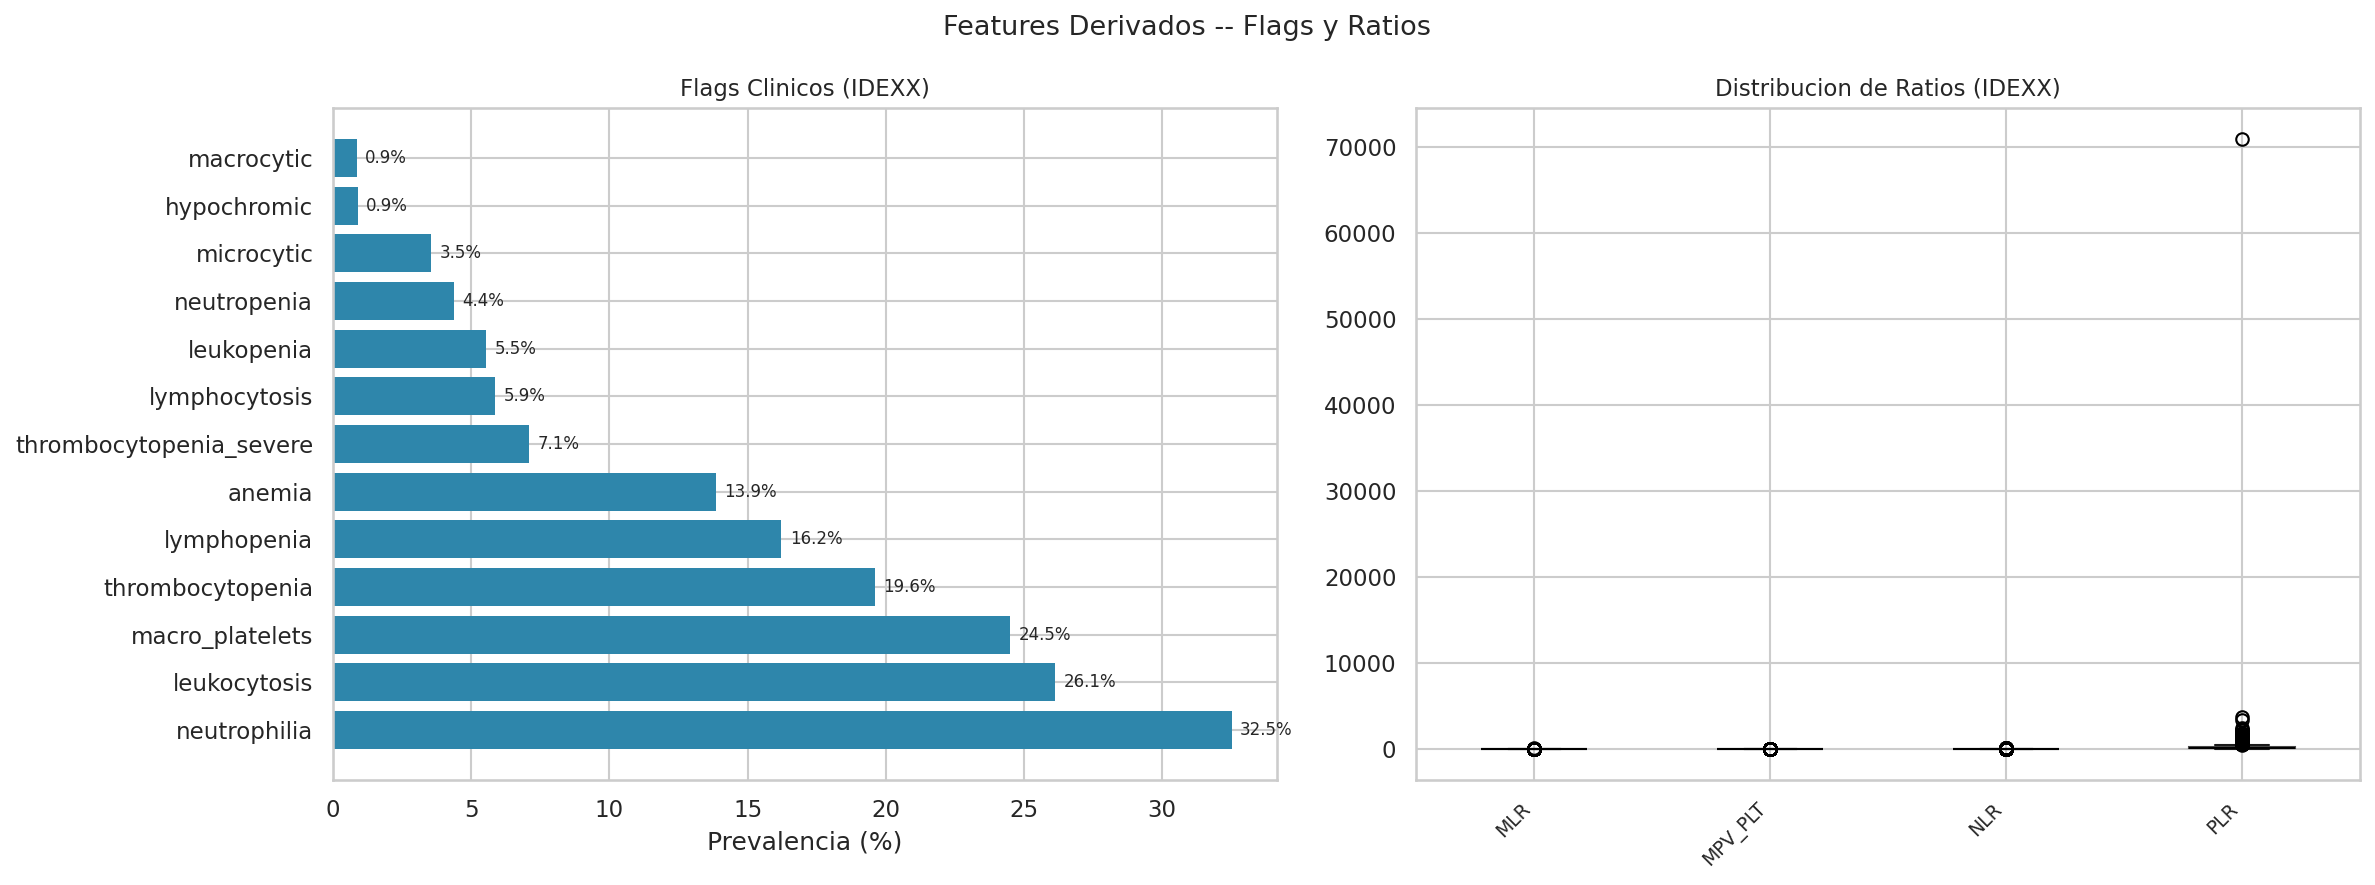

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb03_features_derivados.png


In [18]:
# Panel izquierdo: prevalencia de flags clinicos
# Panel derecho: boxplots de ratios
flag_cols = sorted([c for c in df.columns if c.startswith("flag_")])
ratio_cols_viz = sorted([c for c in df.columns if c.startswith("ratio_")])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prevalencia de flags
idexx_subset = df[df["source_dataset"] == "IDEXX"]
if len(flag_cols) > 0:
    prevalences = [(c, idexx_subset[c].mean() * 100) for c in flag_cols]
    prevalences.sort(key=lambda x: x[1], reverse=True)
    names = [p[0].replace("flag_", "") for p in prevalences]
    vals = [p[1] for p in prevalences]
    bars = ax1.barh(names, vals, color="#2E86AB", edgecolor="none")
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{v:.1f}%", va="center", fontsize=8)
    ax1.set_xlabel("Prevalencia (%)")
    ax1.set_title("Flags Clinicos (IDEXX)", fontsize=11)
else:
    ax1.text(0.5, 0.5, "Sin flags", ha="center", va="center")

# Boxplots de ratios
if len(ratio_cols_viz) > 0:
    data_ratios = idexx_subset[ratio_cols_viz].dropna(how="all")
    data_ratios.boxplot(ax=ax2, vert=True, patch_artist=True,
                        boxprops=dict(facecolor="#F6AE2D", alpha=0.7),
                        medianprops=dict(color="black"))
    ax2.set_xticklabels([c.replace("ratio_", "") for c in ratio_cols_viz],
                        rotation=45, ha="right", fontsize=9)
    ax2.set_title("Distribucion de Ratios (IDEXX)", fontsize=11)
else:
    ax2.text(0.5, 0.5, "Sin ratios", ha="center", va="center")

plt.suptitle("Features Derivados -- Flags y Ratios", fontsize=13)
plt.tight_layout()
save_and_show(fig, "nb03_features_derivados.png")

---
## 4. Codificacion de variables morfologicas DAP (Modulo 2C)

El dataset DAP contiene anotaciones morfologicas textuales que deben
convertirse a variables binarias:

- **wbc_morphology_1:** `Dohle Bodies` y `Reactive Lymphocytes` indican activacion
  inmune activa. `Unremarkable` indica morfologia normal.
- **rbc_morphology_1:** `Polychromasia` indica regeneracion eritroide.
- **plt_morphology_1:** `Clumped` indica pseudo-trombocitopenia (agregados
  plaquetarios que falsean el conteo automatico).

Solo se aplica a registros DAP; los registros IDEXX reciben NaN
(ausencia de informacion, no valor cero).

In [19]:
def encode_morphology_dap(df: pd.DataFrame) -> pd.DataFrame:
    """
    Codifica variables morfologicas del DAP como features binarias.
    Solo se aplica a registros DAP; IDEXX recibe NaN.
    """
    d = df.copy()
    dap_mask = d["source_dataset"] == "DAP"

    # WBC morfologia
    if "wbc_morphology_1" in d.columns:
        d["morph_dohle_bodies"] = np.where(
            dap_mask,
            (d["wbc_morphology_1"] == "Dohle Bodies").astype(int),
            np.nan,
        )
        d["morph_reactive_lymphocytes"] = np.where(
            dap_mask,
            (d["wbc_morphology_1"] == "Reactive Lymphocytes").astype(int),
            np.nan,
        )
        d["morph_wbc_unremarkable"] = np.where(
            dap_mask,
            (d["wbc_morphology_1"] == "Unremarkable").astype(int),
            np.nan,
        )

    # RBC morfologia
    if "rbc_morphology_1" in d.columns:
        d["morph_polychromasia"] = np.where(
            dap_mask,
            (d["rbc_morphology_1"] == "Polychromasia").astype(int),
            np.nan,
        )

    # Plaquetas morfologia -- pseudo-trombocitopenia
    if "plt_morphology_1" in d.columns:
        d["morph_plt_clumped"] = np.where(
            dap_mask,
            (d["plt_morphology_1"] == "Clumped").astype(int),
            np.nan,
        )

    morph_cols = [c for c in d.columns if c.startswith("morph_")]
    print(f"Variables morfologicas codificadas: {len(morph_cols)}")
    for c in morph_cols:
        dap_vals = d.loc[dap_mask, c]
        positivos = int(dap_vals.sum()) if dap_vals.notna().any() else 0
        print(f"  {c:<35} positivos en DAP: {positivos:>4}")

    return d

df = encode_morphology_dap(df)

Variables morfologicas codificadas: 5
  morph_dohle_bodies                  positivos en DAP:   87
  morph_reactive_lymphocytes          positivos en DAP:   57
  morph_wbc_unremarkable              positivos en DAP: 1093
  morph_polychromasia                 positivos en DAP:   65
  morph_plt_clumped                   positivos en DAP:  476


---
## 5. Resumen de variables nuevas y guardado

Se listan todas las variables generadas en esta fase y se guarda el
dataset con features como `featured_raw.csv`.

In [20]:
# Identificar todas las columnas nuevas
prefixes = ("flag_", "ratio_", "pattern_", "morph_", "extraction_error")
new_cols = [c for c in df.columns if c.startswith(prefixes)]

print(f"Variables nuevas generadas en esta fase: {len(new_cols)}")
print("-" * 60)
for c in sorted(new_cols):
    dtype = df[c].dtype
    n_valid = df[c].notna().sum()
    print(f"  {c:<35} dtype={str(dtype):<8} validos={n_valid:,}")

Variables nuevas generadas en esta fase: 24
------------------------------------------------------------
  extraction_error                    dtype=bool     validos=3,755
  flag_anemia                         dtype=int64    validos=3,755
  flag_hypochromic                    dtype=int64    validos=3,755
  flag_leukocytosis                   dtype=int64    validos=3,755
  flag_leukopenia                     dtype=int64    validos=3,755
  flag_lymphocytosis                  dtype=int64    validos=3,755
  flag_lymphopenia                    dtype=int64    validos=3,755
  flag_macro_platelets                dtype=int64    validos=3,755
  flag_macrocytic                     dtype=int64    validos=3,755
  flag_microcytic                     dtype=int64    validos=3,755
  flag_neutropenia                    dtype=int64    validos=3,755
  flag_neutrophilia                   dtype=int64    validos=3,755
  flag_thrombocytopenia               dtype=int64    validos=3,755
  flag_thrombocytopenia_

In [21]:
# Guardar dataset con features
FEATURED_CSV = DATA_INTERIM / "featured_raw.csv"
df.to_csv(FEATURED_CSV, index=False)
print(f"Guardado: {FEATURED_CSV}")
print(f"Registros: {len(df):,}")
print(f"Columnas totales: {len(df.columns)}")

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/data/interim/featured_raw.csv
Registros: 3,755
Columnas totales: 113


### Nota sobre exclusion de variables del analizador IDEXX

Las variables flag H/L del analizador IDEXX (`Platelets_flag`, `Lymphocytes_flag`,
`Hematocrit_flag`, etc.) **no se incluyen** en el conjunto de features de
entrenamiento. Estas variables son generadas por el mismo sistema de alerta del
analizador que el modelo pretende mejorar: su inclusion introduciria circularidad
(data leakage). Se documentan aqui para la Fase 3.

In [22]:
# Listar las columnas flag H/L que se excluiran en Fase 3
analyzer_flags = [c for c in df.columns if c.endswith("_flag")]
print(f"Columnas flag del analizador IDEXX a excluir del entrenamiento ({len(analyzer_flags)}):")
for c in sorted(analyzer_flags):
    print(f"  {c}")

Columnas flag del analizador IDEXX a excluir del entrenamiento (18):
  Basophils_flag
  Eosinophils_flag
  Hematocrit_flag
  Hemoglobin_flag
  Lymphocytes_flag
  MCHC_flag
  MCH_flag
  MCV_flag
  MPV_flag
  Monocytes_flag
  Neutrophils_flag
  PDW_flag
  Plateletcrit_flag
  Platelets_flag
  RBC_flag
  RDW_flag
  Reticulocytes_flag
  WBC_flag


---
## 6. Verificacion de integridad

Se comprueba que los criterios de aceptacion definidos en el documento
de Fase 2 se cumplen para `featured_raw.csv`.

In [23]:
# Criterio 1: Integridad de features criticas en subconjunto IDEXX
idexx_check = df[df["source_dataset"] == "IDEXX"]
critical_features = ["flag_thrombocytopenia", "flag_lymphopenia", "ratio_NLR"]
print("Criterio 1 -- Completitud de features criticas (IDEXX):")
all_pass = True
for feat in critical_features:
    n_null = idexx_check[feat].isna().sum()
    status = "OK" if n_null == 0 else "FALLO"
    if n_null > 0:
        all_pass = False
    print(f"  {feat:<35} nulos={n_null:>4}  [{status}]")

# Criterio DAP
dap_check = df[df["source_dataset"] == "DAP"]
print("\nCriterio 1 -- Completitud de features criticas (DAP, umbral >98%):")
for feat in critical_features:
    pct = dap_check[feat].notna().mean() * 100
    status = "OK" if pct >= 98 else "FALLO"
    if pct < 98:
        all_pass = False
    print(f"  {feat:<35} completitud={pct:.1f}%  [{status}]")

# Criterio 3: Sin fuga de informacion
print("\nCriterio 3 -- Features derivadas calculadas sobre valores brutos (no flags H/L):")
leak_cols = [c for c in new_cols if c in analyzer_flags]
if len(leak_cols) == 0:
    print("  Sin fuga de informacion detectada [OK]")
else:
    all_pass = False
    print(f"  FALLO: {leak_cols}")

print()
if all_pass:
    print("Todos los criterios de integridad se cumplen.")
else:
    print("Algunos criterios no se cumplen. Revisar las secciones anteriores.")

Criterio 1 -- Completitud de features criticas (IDEXX):
  flag_thrombocytopenia               nulos=   0  [OK]
  flag_lymphopenia                    nulos=   0  [OK]
  ratio_NLR                           nulos=  25  [FALLO]

Criterio 1 -- Completitud de features criticas (DAP, umbral >98%):
  flag_thrombocytopenia               completitud=100.0%  [OK]
  flag_lymphopenia                    completitud=100.0%  [OK]
  ratio_NLR                           completitud=99.8%  [OK]

Criterio 3 -- Features derivadas calculadas sobre valores brutos (no flags H/L):
  Sin fuga de informacion detectada [OK]

Algunos criterios no se cumplen. Revisar las secciones anteriores.


---
**Fin del Notebook 03.** El dataset `featured_raw.csv` esta listo para el
etiquetado clinico en el Notebook 04.